# 1. Import libaries

In [41]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 2. Aggregate transactions by customer

In [2]:
# Load cleaned data
raw_data_cleaned = pd.read_parquet("data/staging/raw_data_cleaned.parquet", engine= "pyarrow")
raw_data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      6000 non-null   str           
 1   gender           6000 non-null   str           
 2   age_group        6000 non-null   str           
 3   city             6000 non-null   str           
 4   signup_date      6000 non-null   datetime64[us]
 5   order_id         6000 non-null   str           
 6   order_date       6000 non-null   datetime64[us]
 7   restaurant_name  6000 non-null   str           
 8   dish_name        6000 non-null   str           
 9   category         6000 non-null   str           
 10  quantity         6000 non-null   int64         
 11  price            6000 non-null   float64       
 12  payment_method   6000 non-null   str           
 13  order_frequency  6000 non-null   int64         
 14  last_order_date  6000 non-null   datetime64[us]
 15

In [3]:
# Define lastest transaction date
anchor_date = raw_data_cleaned['order_date'].max() + pd.Timedelta(days=1)
anchor_date

Timestamp('2025-08-23 00:00:00')

In [4]:
rfm_df = raw_data_cleaned.copy()

# Calculate RFM values
rfm_df['recency'] = (anchor_date - rfm_df['last_order_date']).dt.days
rfm_df['frequency'] = rfm_df['order_frequency']
rfm_df['monetary'] = rfm_df['value']
rfm_df.head()

,customer_id,gender,age_group,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,last_order_date,loyalty_points,rating,rating_date,delivery_status,is_churned,value,recency,frequency,monetary
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,...,2025-07-19,238,3,2024-10-14,Cancelled,0,7391.35,35,38,7391.35
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,...,2024-11-25,81,2,2025-08-21,Delayed,0,2868.12,271,24,2868.12
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,2025-05-10,82,3,2024-09-19,Delayed,1,1765.02,105,42,1765.02
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,...,2025-07-24,45,2,2025-06-29,Delayed,1,925.20,30,27,925.20
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,...,2024-12-21,418,3,2025-03-06,Cancelled,1,1156.69,245,35,1156.69


In [5]:
# Retain important features
rfm_df = rfm_df[
    [
    'customer_id',
    'recency',
    'frequency',
    'monetary',
    'loyalty_points',
    'rating',
    'quantity',
    'gender',
    'age_group',
    'city',
    'is_churned'
    ]
]
rfm_df.head()

,customer_id,recency,frequency,monetary,loyalty_points,rating,quantity,gender,age_group,city,is_churned
0,C5663,35,38,7391.35,238,3,5,Male,Adult,Peshawar,0
1,C2831,271,24,2868.12,81,2,3,Male,Adult,Multan,0
2,C2851,105,42,1765.02,82,3,2,Other,Senior,Multan,1
3,C1694,30,27,925.20,45,2,4,Female,Senior,Peshawar,1
4,C4339,245,35,1156.69,418,3,1,Other,Senior,Lahore,1


# 4. Analyze RFM Values

In [6]:
# Check for skewness
rfm_df[['recency', 'frequency', 'monetary']].describe([.01, .03, .05, .95, .97, .99])

,recency,frequency,monetary
count,6000.000000,6000.000000,6000.000000
mean,183.669500,25.304667,2390.652013
std,105.777429,14.358930,1754.874758
min,2.000000,1.000000,101.730000
1%,5.000000,1.000000,169.072200
3%,11.000000,2.000000,275.869500
5%,18.000000,3.000000,364.887000
95%,349.000000,48.000000,5884.258500
97%,356.000000,49.000000,6456.121000
99%,364.000000,50.000000,7207.771500


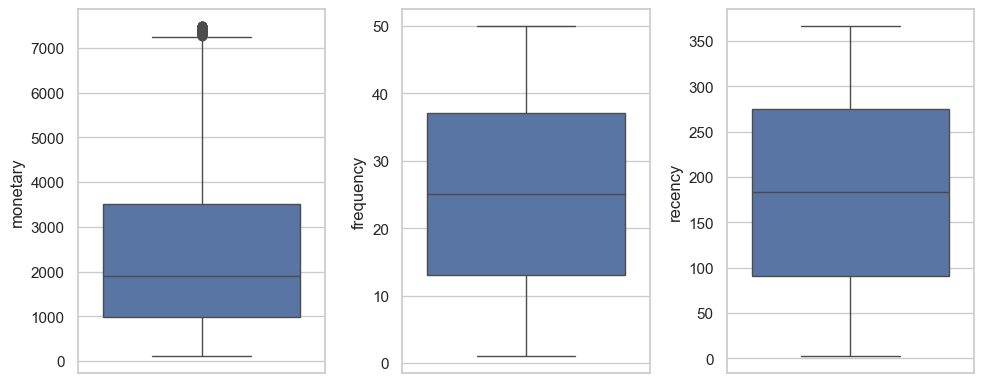

In [7]:
# Detect outliers
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(ncols= 3, figsize= (10, 4))
sns.boxplot(rfm_df['monetary'], ax= axs[0])
sns.boxplot(rfm_df['frequency'], ax= axs[1])
sns.boxplot(rfm_df['recency'], ax= axs[2])
plt.tight_layout()

> R,F,M values spread nicely with no outliers

# 3. Calculate RFM Scores

In [28]:
rfm_df_score = rfm_df.copy()

In [29]:
# Calculate RFM scores using quintiles
rfm_df_score['r_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm_df_score['f_score'] = pd.qcut(rfm_df['frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm_df_score['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5]).astype(int)

In [32]:
# Get the mean scores of Monetary and Frequency
rfm_df_score['fm_score'] = rfm_df_score[['f_score','m_score']].sum(axis=1)

In [33]:
# Re bin the fm score
rfm_df_score['fm_score'] = pd.cut(
    rfm_df_score['fm_score'],
    bins=[1, 3, 5, 6, 8, 10],
    labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_df_score.head()

,customer_id,recency,frequency,monetary,loyalty_points,rating,quantity,gender,age_group,city,is_churned,r_score,f_score,m_score,fm_score
0,C5663,35,38,7391.35,238,3,5,Male,Adult,Peshawar,0,5,4,5,5
1,C2831,271,24,2868.12,81,2,3,Male,Adult,Multan,0,2,3,4,4
2,C2851,105,42,1765.02,82,3,2,Other,Senior,Multan,1,4,5,3,4
3,C1694,30,27,925.20,45,2,4,Female,Senior,Peshawar,1,5,3,2,2
4,C4339,245,35,1156.69,418,3,1,Other,Senior,Lahore,1,2,4,2,3


# 4. Classic RFM Segments

In [34]:
rfm_classic = rfm_df_score.copy()

In [35]:
# Define rule table
rfm_rule_table = pd.DataFrame([
    {"segment": "1. Champions",         "r_min": 5,   "r_max": 5,   "m_min": 4,   "m_max": 5},
    {"segment": "2. Loyalist",          "r_min": 3,   "r_max": 4,   "m_min": 4,   "m_max": 5},
    {"segment": "3. Potential Loyalist","r_min": 4,   "r_max": 5,   "m_min": 2,   "m_max": 3},
    {"segment": "4. New Customers",     "r_min": 5,   "r_max": 5,   "m_min": 1,   "m_max": 1},
    {"segment": "5. Promising",         "r_min": 4,   "r_max": 4,   "m_min": 1,   "m_max": 1},
    {"segment": "6. Need Attention",    "r_min": 3,   "r_max": 3,   "m_min": 3,   "m_max": 3},
    {"segment": "7. About To Sleep",    "r_min": 3,   "r_max": 3,   "m_min": 1,   "m_max": 2},
    {"segment": "8. Can't Lose",        "r_min": 1,   "r_max": 2,   "m_min": 5,   "m_max": 5},
    {"segment": "9. At Risk",           "r_min": 1,   "r_max": 2,   "m_min": 3,   "m_max": 4},
    {"segment": "10. Hibernating",      "r_min": 1,   "r_max": 2,   "m_min": 1,   "m_max": 2},
])
rfm_rule_table

,segment,r_min,r_max,m_min,m_max
0,1. Champions,5,5,4,5
1,2. Loyalist,3,4,4,5
2,3. Potential Loyalist,4,5,2,3
3,4. New Customers,5,5,1,1
4,5. Promising,4,4,1,1
5,6. Need Attention,3,3,3,3
6,7. About To Sleep,3,3,1,2
7,8. Can't Lose,1,2,5,5
8,9. At Risk,1,2,3,4
9,10. Hibernating,1,2,1,2


In [36]:
# Row-wise segmentation
conditions = []
choices = []

for _, rule in rfm_rule_table.iterrows():
    cond = (
        (rfm_classic['r_score'] >= rule['r_min']) & (rfm_classic['r_score'] <= rule['r_max']) &
        (rfm_classic['fm_score'] >= rule['m_min']) & (rfm_classic['fm_score'] <= rule['m_max'])
    )
    conditions.append(cond)
    choices.append(rule['segment'])
    
rfm_classic['rfm_classic_segment'] = np.select(conditions, choices, default='Unclassified')

In [37]:
rfm_classic.head(10)

,customer_id,recency,frequency,monetary,loyalty_points,rating,quantity,gender,age_group,city,is_churned,r_score,f_score,m_score,fm_score,rfm_classic_segment
0,C5663,35,38,7391.35,238,3,5,Male,Adult,Peshawar,0,5,4,5,5,1. Champions
1,C2831,271,24,2868.12,81,2,3,Male,Adult,Multan,0,2,3,4,4,9. At Risk
2,C2851,105,42,1765.02,82,3,2,Other,Senior,Multan,1,4,5,3,4,2. Loyalist
3,C1694,30,27,925.20,45,2,4,Female,Senior,Peshawar,1,5,3,2,2,3. Potential Loyalist
4,C4339,245,35,1156.69,418,3,1,Other,Senior,Lahore,1,2,4,2,3,9. At Risk
5,C6543,317,45,6068.10,418,4,5,Other,Adult,Karachi,1,1,5,5,5,8. Can't Lose
6,C6423,90,31,3364.55,347,3,5,Male,Adult,Lahore,0,4,4,4,4,2. Loyalist
7,C4621,114,14,543.48,429,2,2,Male,Adult,Peshawar,0,4,2,1,1,5. Promising
8,C5146,99,1,2984.80,24,4,5,Other,Senior,Karachi,0,4,1,4,2,3. Potential Loyalist
9,C3579,181,15,2886.50,270,3,2,Male,Adult,Karachi,1,3,2,4,3,6. Need Attention


In [38]:
rfm_classic['rfm_classic_segment'].value_counts().sort_index()

rfm_classic_segment
1. Champions              468
10. Hibernating          1012
2. Loyalist               964
3. Potential Loyalist    1182
4. New Customers          141
5. Promising              144
6. Need Attention         254
7. About To Sleep         452
8. Can't Lose             286
9. At Risk               1097
Name: count, dtype: int64

# 5. Visualize Classic RFM Segments

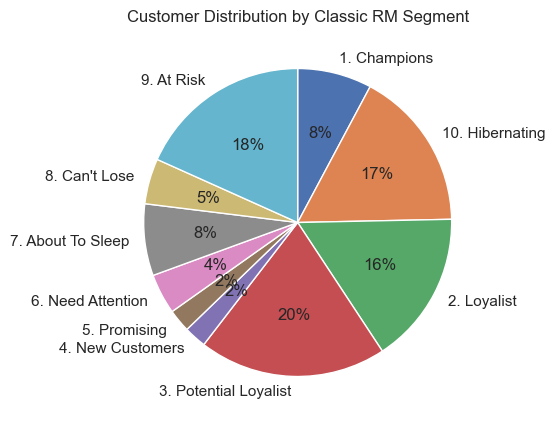

In [39]:
# Plot pie chart to show pct of each rm_segment
rfm_classic['rfm_classic_segment'].value_counts().sort_index(ascending=True).plot.pie(
    figsize=(6, 5),
    autopct='%1.0f%%',
    startangle=90,
    counterclock=False,
    ylabel='',  # Removes the default y-label
    title='Customer Distribution by Classic RM Segment'
)
plt.show()

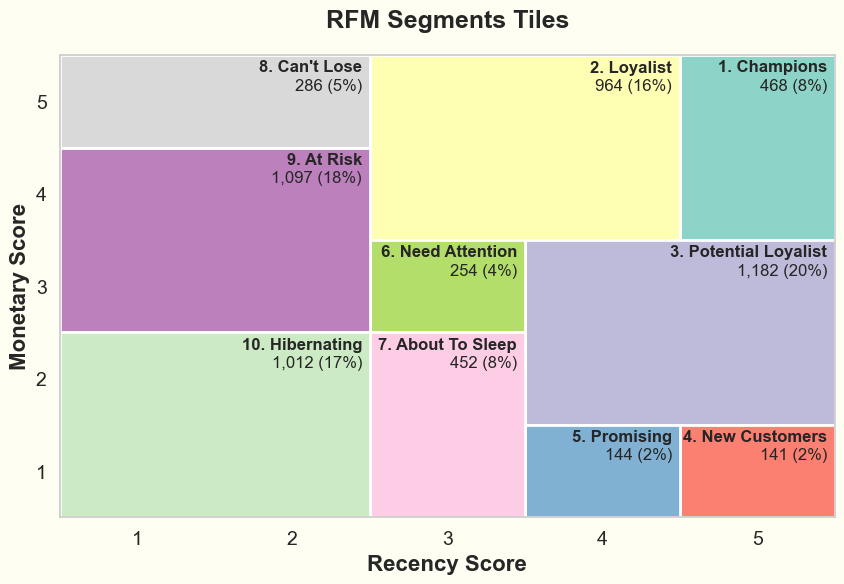

In [43]:
# Prepare colors for segments
unique_segments = rfm_rule_table['segment'].tolist()
n_segments = len(unique_segments)
cmap = plt.colormaps.get_cmap('Set3')  # Softer palette
colors = [cmap(i / n_segments) for i in range(n_segments)]
segment_colors = {seg: colors[i] for i, seg in enumerate(unique_segments)}

# Total number of customers
total_customers = len(rfm_classic)

plt.figure(figsize=(10, 6), facecolor='#FFFEF2')
ax = plt.gca()
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xlabel('Recency Score', fontsize=16, fontweight='bold')
ax.set_ylabel('Monetary Score', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_title(f'RFM Segments Tiles', fontsize=18, fontweight='bold', pad=20)

for _, row in rfm_rule_table.iterrows():
    segment = row['segment']
    r_min, r_max = row['r_min'], row['r_max']
    m_min, m_max = row['m_min'], row['m_max']

    # Calculate width and height of the rectangle
    width = r_max - r_min + 1
    height = m_max - m_min + 1

    # Draw rectangle for the segment
    rect = Rectangle((r_min - 0.5, m_min - 0.5), width, height,
                     facecolor=segment_colors[segment],
                     edgecolor='white', linewidth=2)
    ax.add_patch(rect)

    # Filter customers in this segment
    subset = rfm_classic[rfm_classic['rfm_classic_segment'] == segment]
    count = len(subset)
    percent = count / total_customers * 100

    # Position text at top-right corner with padding
    text_x = r_max + 0.45
    text_y = m_max + 0.45

    # Add segment name and count + percentage
    ax.text(text_x, text_y, segment, ha='right', va='top', wrap=True, fontweight='bold')
    ax.text(text_x, text_y - 0.2, f"{count:,} ({percent:.0f}%)", ha='right', va='top', wrap=True, fontsize=12)

plt.grid(False)
plt.show()